# 📈 Pricing des Options Parisiennes
### CY Paris-Cergy Université — CY TECH
**Projet ING2 Mathématiques Financières 2025-2026**

---

Ce notebook présente la valorisation par **simulation Monte-Carlo** de deux familles d'options exotiques :

- **Livrable I** : Options à Barrière classiques (Down/Up, In/Out — 8 types)
- **Livrable II** : Options Parisiennes Cumulatives et Continues — sensibilités et VaR

**Dynamique du sous-jacent** (modèle Black-Scholes) :
$$S(t_{i+1}) = S(t_i)\exp\!\left[\!\left(r - \frac{\sigma^2}{2}\right)\!\Delta t + \sigma\sqrt{\Delta t}\, g_i\right], \quad g_i\sim\mathcal{N}(0,1)\text{ i.i.d.}$$

**Paramètres communs (Livrable I) :** $S_0=100,\; K=100,\; r=0.04,\; \sigma=0.3,\; T=5,\; B=80$

## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
np.random.seed(42)  # Reproductibilité

---
# Livrable I — Options à Barrière

Une option à barrière est une option dont l'existence dépend du franchissement d'un seuil (la **barrière** $B$) par le sous-jacent au cours de sa vie.

| Type | Mécanisme |
|------|-----------|
| **Down-and-In** | S'active si $S(t_i) \leq B$ |
| **Down-and-Out** | Désactivée si $S(t_i) \leq B$ |
| **Up-and-In** | S'active si $S(t_i) \geq B$ |
| **Up-and-Out** | Désactivée si $S(t_i) \geq B$ |

## 1.1 Option Down-and-In Put

Le **Put Down-and-In (PDI)** s'active uniquement si le sous-jacent touche la barrière $B$ à la baisse au moins une fois pendant la vie de l'option. Son pay-off est :
$$\Phi(S) = \max(K - S(T), 0) \cdot \mathbf{1}_{\exists\, t_i : S(t_i) \leq B}$$

On trace le graphe $S_0 \mapsto V(0, S_0)$ par Monte-Carlo.

Prix de l'option Down-and-In Put pour S0=100 : 15.8551


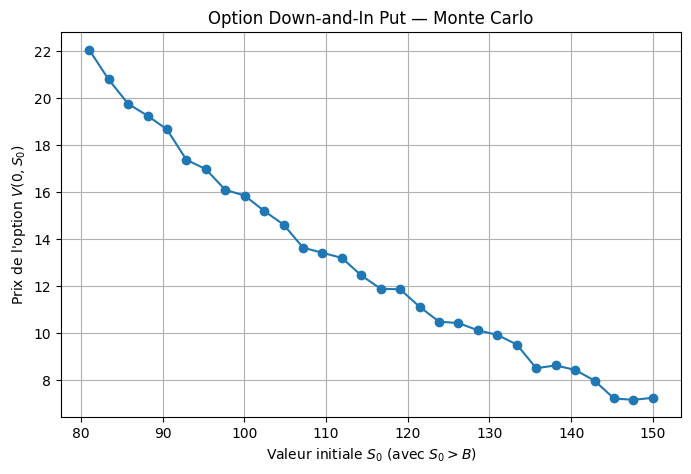

In [5]:
# ─── Paramètres Livrable I ───
B = 80
K = 100
r = 0.04
sigma = 0.3
T = 5
N = 500
dt = T / N
Nmc = 5000

# S0 strictement supérieur à la barrière
S0_values = np.linspace(B + 1, 150, 30)
prix_option = []

for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0
        trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
            trajectoire.append(S)
        # Activation Down-and-In : au moins un S(ti) <= B
        if np.min(trajectoire) <= B:
            payoff.append(max(K - trajectoire[-1], 0))
        else:
            payoff.append(0)
    prix = np.exp(-r * T) * np.mean(payoff)
    prix_option.append(prix)

# Calcul pour S0 = 100
idx_100 = np.argmin(np.abs(S0_values - 100))
print(f'Prix de l\'option Down-and-In Put pour S0=100 : {prix_option[idx_100]:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$ (avec $S_0 > B$)')
plt.ylabel('Prix de l\'option $V(0,S_0)$')
plt.title('Option Down-and-In Put — Monte Carlo')
plt.grid()
plt.show()

## 1.2 Grecques — Delta par Différences Finies

Le **Delta** mesure la sensibilité du prix de l'option à une variation de $S_0$. On l'approche par différences finies centrées :
$$\Delta(S_0, 0) = e^{-rT}\,\mathbb{E}\!\left[\frac{\Phi(S^{h+}(T)) - \Phi(S^{h-}(T))}{2h}\right]$$
Les deux trajectoires $S^{h+}$ (partant de $S_0+h$) et $S^{h-}$ (partant de $S_0-h$) utilisent les **mêmes** $g_i$ (réduction de variance par variables corrélées).

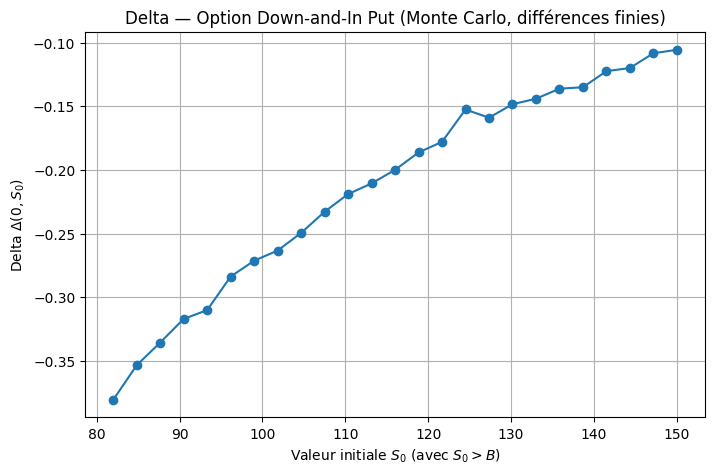

In [6]:
# ─── Delta de l'option Down-and-In Put ───
h = 1
B = 80; K = 100; r = 0.04; sigma = 0.3; T = 5
N = 500; dt = T / N; Nmc = 5000

S0_values = np.linspace(B + h + 1, 150, 25)
delta_values = []

for S0 in S0_values:
    delta_mc = []
    for k in range(Nmc):
        Splus  = S0 + h
        Smoins = S0 - h
        traj_plus  = [Splus]
        traj_moins = [Smoins]
        # Mêmes incréments gaussiens pour les deux trajectoires
        Z = np.random.randn(N)
        for i in range(N):
            Splus  = Splus  * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[i])
            Smoins = Smoins * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[i])
            traj_plus.append(Splus)
            traj_moins.append(Smoins)
        # Payoffs avec condition d'activation de la barrière
        payoff_plus  = max(K - traj_plus[-1],  0) if np.min(traj_plus)  <= B else 0
        payoff_moins = max(K - traj_moins[-1], 0) if np.min(traj_moins) <= B else 0
        delta_mc.append((payoff_plus - payoff_moins) / (2 * h))
    delta = np.exp(-r * T) * np.mean(delta_mc)
    delta_values.append(delta)

plt.figure(figsize=(8, 5))
plt.plot(S0_values, delta_values, marker='o')
plt.xlabel('Valeur initiale $S_0$ (avec $S_0 > B$)')
plt.ylabel('Delta $\\Delta(0,S_0)$')
plt.title('Delta — Option Down-and-In Put (Monte Carlo, différences finies)')
plt.grid()
plt.show()

## 1.3 Les 8 Types d'Options à Barrière

On calcule et trace le graphe $S_0 \mapsto V(0, S_0)$ pour les 8 combinaisons Put/Call × In/Out × Down/Up.

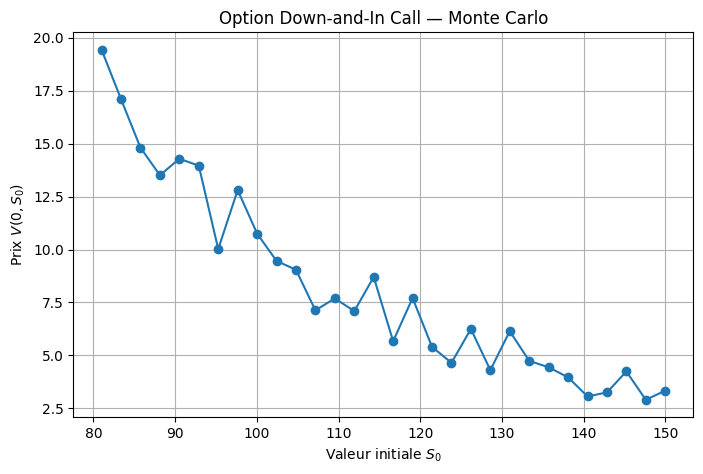

In [7]:
# ─── Down-and-In Call ───
# S'active si le sous-jacent descend sous B ; pay-off = max(S(T)-K, 0)
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=1000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) <= B:
            payoff.append(max(trajectoire[-1]-K, 0))
        else:
            payoff.append(0)
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Down-and-In Call — Monte Carlo'); plt.grid(); plt.show()

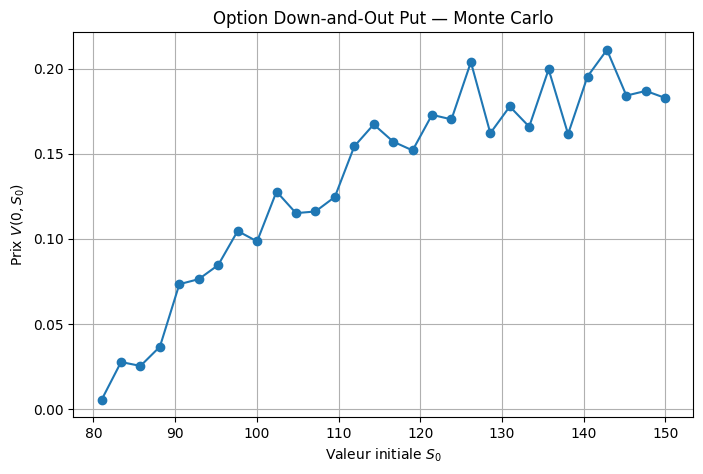

In [8]:
# ─── Down-and-Out Put ───
# Désactivée si le sous-jacent descend sous B ; pay-off = max(K-S(T), 0)
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=5000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) <= B:
            payoff.append(0)
        else:
            payoff.append(max(K - trajectoire[-1], 0))
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Down-and-Out Put — Monte Carlo'); plt.grid(); plt.show()

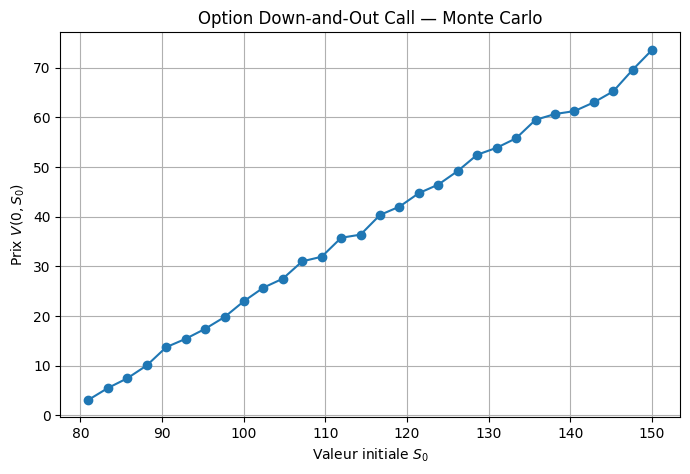

In [9]:
# ─── Down-and-Out Call ───
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=5000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) <= B:
            payoff.append(0)
        else:
            payoff.append(max(trajectoire[-1]-K, 0))
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Down-and-Out Call — Monte Carlo'); plt.grid(); plt.show()

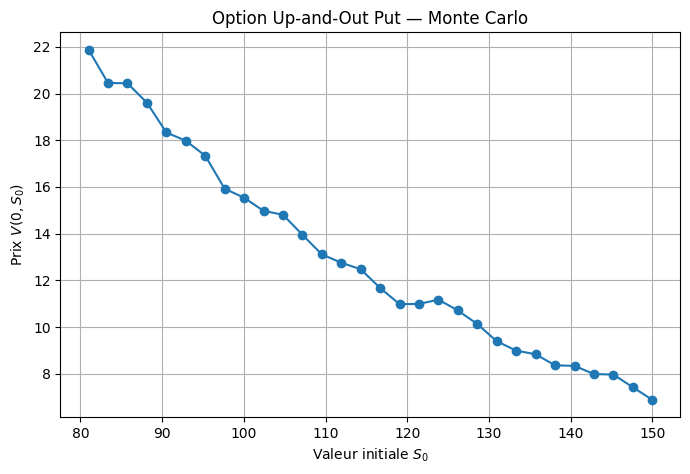

In [10]:
# ─── Up-and-Out Put ───
# Désactivée si le sous-jacent monte au-dessus de B
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=5000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) >= B:
            payoff.append(0)
        else:
            payoff.append(max(K - trajectoire[-1], 0))
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Up-and-Out Put — Monte Carlo'); plt.grid(); plt.show()

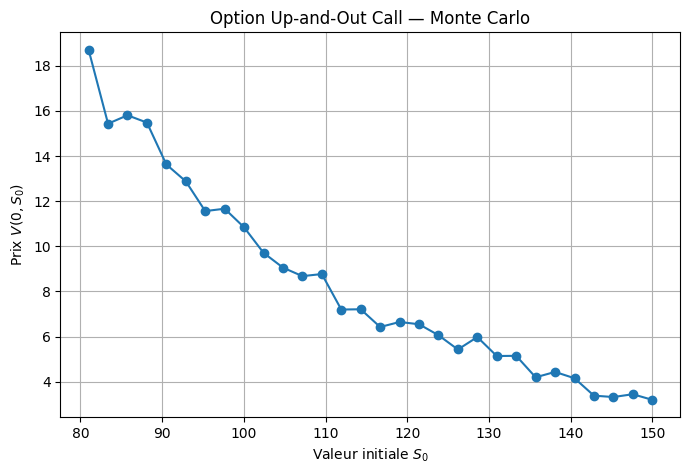

In [11]:
# ─── Up-and-Out Call ───
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=5000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) >= B:
            payoff.append(0)
        else:
            payoff.append(max(trajectoire[-1]-K, 0))
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Up-and-Out Call — Monte Carlo'); plt.grid(); plt.show()

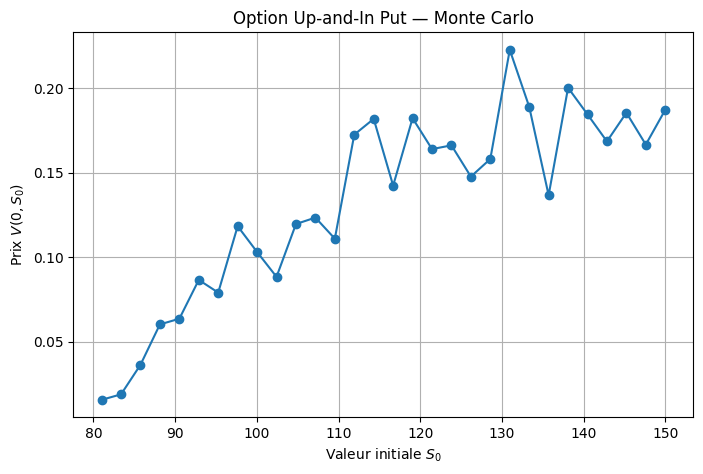

In [12]:
# ─── Up-and-In Put ───
# S'active si le sous-jacent monte au-dessus de B au moins une fois
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=5000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) >= B:
            payoff.append(max(K - trajectoire[-1], 0))
        else:
            payoff.append(0)
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Up-and-In Put — Monte Carlo'); plt.grid(); plt.show()

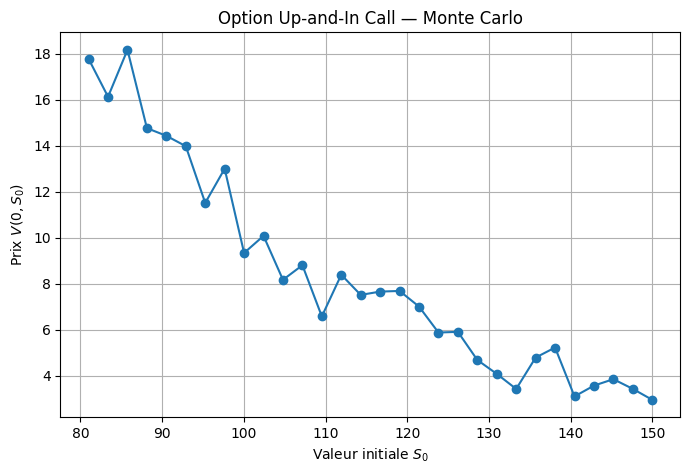

In [13]:
# ─── Up-and-In Call ───
B=80; K=100; r=0.04; sigma=0.3; T=5; N=500; dt=T/N; Nmc=1000
S0_values = np.linspace(B+1, 150, 30)
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        if np.min(trajectoire) <= B:
            payoff.append(max(trajectoire[-1]-K, 0))
        else:
            payoff.append(0)
    prix_option.append(np.exp(-r*T)*np.mean(payoff))
plt.figure(figsize=(8,5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('Valeur initiale $S_0$'); plt.ylabel('Prix $V(0,S_0)$')
plt.title('Option Up-and-In Call — Monte Carlo'); plt.grid(); plt.show()

---
# Livrable II — Options Parisiennes

Une **option Parisienne** est une variante des options à barrière dans laquelle la condition d'activation/désactivation porte non pas sur un simple franchissement de la barrière, mais sur la **durée** passée au-delà de cette barrière.

On distingue deux types :
- **Cumulatif** : la condition porte sur le *temps total cumulé* au-delà de $B$
- **Continu** : la condition porte sur la *plus longue excursion continue* au-delà de $B$

**Paramètres utilisés** : $K=100,\; r=0.04,\; \sigma=0.3,\; T=5,\; B=80,\; N=500$

## Section 3 — Options Parisiennes Cumulatives

**Définition** : La condition d'activation/désactivation est vérifiée quand le temps total cumulé sous (ou au-dessus de) la barrière $B$ dépasse $D_{crit}$ :
$$D_1 + D_2 + \cdots + D_i \geq D_{crit}$$
où $D_k$ est la durée du $k$-ème passage sous/au-dessus de $B$.

In [14]:
# ─── Paramètres Livrable II ───
B = 80
K = 100
r = 0.04
sigma = 0.3
T = 5
N = 500
dt = T / N
Nmc = 3000

S0_values   = np.linspace(B + 1, 150, 20)
Dcrit_values = np.linspace(1, 10, 10)

# ─── Fonction : temps cumulé SOUS la barrière ───
def temps_sous_barriere(trajectoire, B):
    """Calcule le temps total passé sous la barrière B (version interpolée)."""
    D = 0
    for j in range(len(trajectoire) - 1):
        S1 = trajectoire[j]
        S2 = trajectoire[j + 1]
        if S1 < B and S2 < B:
            D += dt
        elif S1 >= B and S2 < B:
            # Entrée sous B : proportion du pas de temps
            D += dt * (B - S2) / (S1 - S2)
        elif S1 < B and S2 >= B:
            # Sortie de sous B
            D += dt * (B - S1) / (S2 - S1)
    return D

# ─── Fonction : temps cumulé AU-DESSUS de la barrière ───
def temps_au_dessus_barriere(trajectoire, B):
    """Calcule le temps total passé au-dessus de la barrière B (version interpolée)."""
    D = 0
    for j in range(len(trajectoire) - 1):
        S1 = trajectoire[j]
        S2 = trajectoire[j + 1]
        if S1 > B and S2 > B:
            D += dt
        elif S1 <= B and S2 > B:
            D += dt * (S2 - B) / (S2 - S1)
        elif S1 > B and S2 <= B:
            D += dt * (S1 - B) / (S1 - S2)
    return D

print('Fonctions helper cumulatives définies.')

Fonctions helper cumulatives définies.


### 3.1 Surface de prix $V(S_0, D_{crit})$ — Down-and-In Put Cumulatif

Pour chaque couple $(S_0, D_{crit})$ on calcule le prix par Monte-Carlo, puis on trace la surface 3D et les coupes.

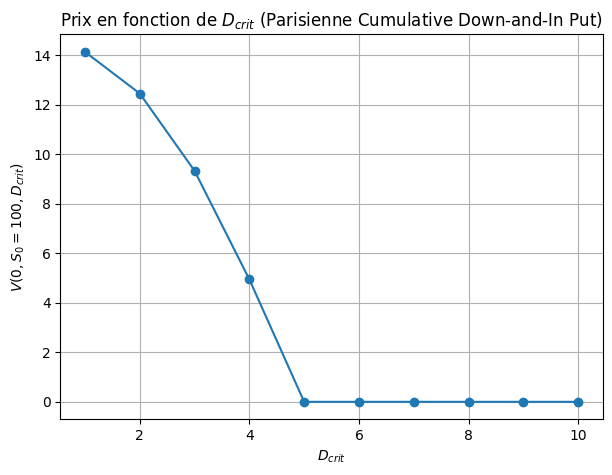

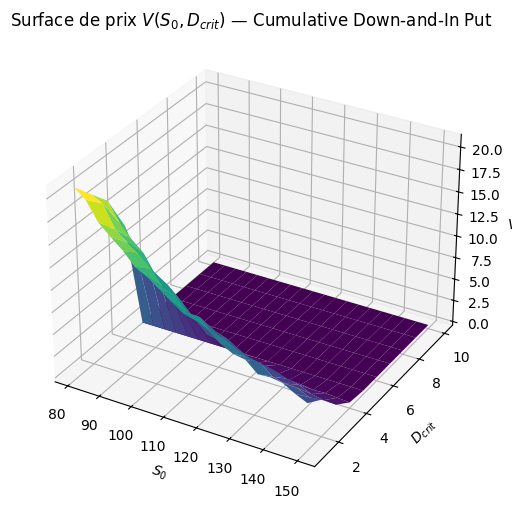

In [15]:
# ─── Surface V(S0, Dcrit) pour la Down-and-In Put Cumulative ───
# L'option s'active si le temps total SOUS B >= Dcrit
prix_surface_cumul = np.zeros((len(S0_values), len(Dcrit_values)))

for i, S0 in enumerate(S0_values):
    for j, Dcrit in enumerate(Dcrit_values):
        payoff = []
        for k in range(Nmc):
            S = S0
            trajectoire = [S]
            for _ in range(N):
                Z = np.random.randn()
                S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
                trajectoire.append(S)
            D = temps_sous_barriere(trajectoire, B)
            if D >= Dcrit:
                payoff.append(max(K - trajectoire[-1], 0))
            else:
                payoff.append(0)
        prix_surface_cumul[i, j] = np.exp(-r*T) * np.mean(payoff)

# ─── Tracé 1 : V en fonction de Dcrit pour S0 fixé ───
S0_fixed = 100
idx = np.argmin(np.abs(S0_values - S0_fixed))
plt.figure(figsize=(7, 5))
plt.plot(Dcrit_values, prix_surface_cumul[idx, :], marker='o')
plt.xlabel('$D_{crit}$')
plt.ylabel(f'$V(0, S_0={S0_fixed}, D_{{crit}})$')
plt.title('Prix en fonction de $D_{crit}$ (Parisienne Cumulative Down-and-In Put)')
plt.grid()
plt.show()

# ─── Tracé 2 : Surface 3D (S0, Dcrit) → V ───
S0_grid, Dcrit_grid = np.meshgrid(S0_values, Dcrit_values, indexing='ij')
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S0_grid, Dcrit_grid, prix_surface_cumul, cmap='viridis')
ax.set_xlabel('$S_0$'); ax.set_ylabel('$D_{crit}$'); ax.set_zlabel('$V$')
ax.set_title('Surface de prix $V(S_0, D_{crit})$ — Cumulative Down-and-In Put')
plt.show()

### 3.2 Graphe $S_0 \mapsto V(0, S_0, D_{crit})$ pour plusieurs $D_{crit}$

On compare les prix pour $D_{crit} = 0,\; 2,\; 4$ afin d'observer l'impact de l'excursion critique.

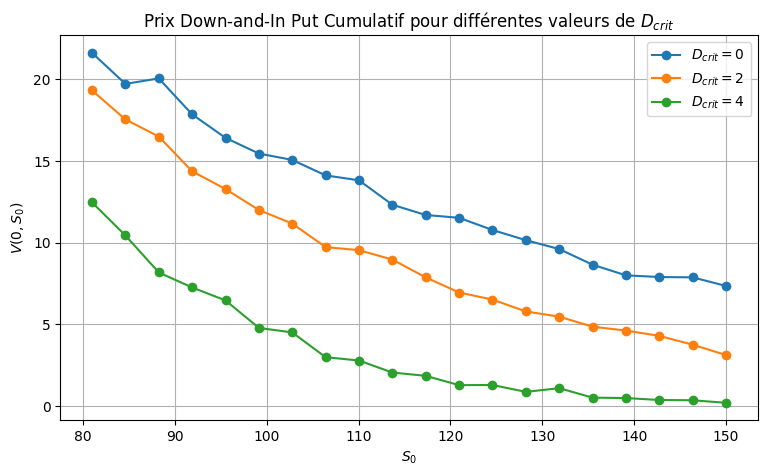

In [16]:
# ─── Graphe S0 → V pour Dcrit = 0, 2, 4 (Down-and-In Put Cumulatif) ───
# Dcrit = 0 : toujours actif (option classique Down-and-In)
Dcrit_list = [0, 2, 4]

plt.figure(figsize=(9, 5))
for Dcrit_val in Dcrit_list:
    prix_tmp = []
    for S0 in S0_values:
        payoff = []
        for k in range(Nmc):
            S = S0
            trajectoire = [S]
            for _ in range(N):
                Z = np.random.randn()
                S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
                trajectoire.append(S)
            D = temps_sous_barriere(trajectoire, B)
            if D >= Dcrit_val:
                payoff.append(max(K - trajectoire[-1], 0))
            else:
                payoff.append(0)
        prix_tmp.append(np.exp(-r*T) * np.mean(payoff))
    plt.plot(S0_values, prix_tmp, marker='o', label=f'$D_{{crit}}={Dcrit_val}$')

plt.xlabel('$S_0$')
plt.ylabel('$V(0, S_0)$')
plt.title('Prix Down-and-In Put Cumulatif pour différentes valeurs de $D_{crit}$')
plt.legend()
plt.grid()
plt.show()

### 3.3 Autres types cumulatifs — Down-and-Out, Up-and-In, Up-and-Out

On calcule maintenant les prix des 3 types restants avec $D_{crit} = 2$.

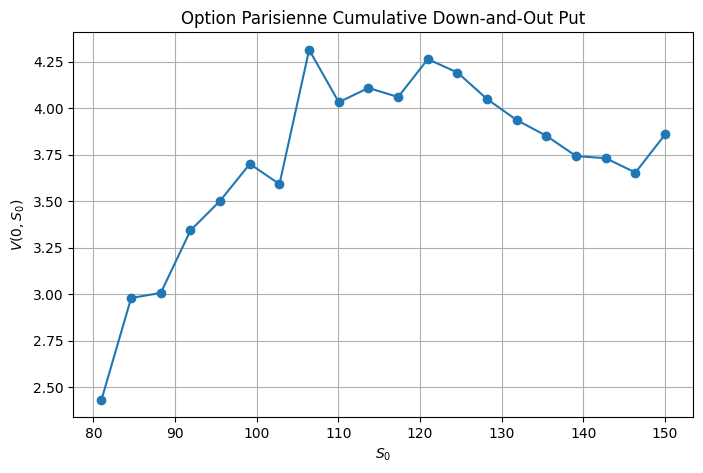

In [17]:
# ─── Down-and-Out Put Cumulatif ───
# L'option CESSE d'exister si le temps total sous B >= Dcrit
Dcrit = 2.0
prix_do_put = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D = temps_sous_barriere(trajectoire, B)
        if D >= Dcrit:
            payoff.append(0)
        else:
            payoff.append(max(K - trajectoire[-1], 0))
    prix_do_put.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values, prix_do_put, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title('Option Parisienne Cumulative Down-and-Out Put')
plt.grid(); plt.show()

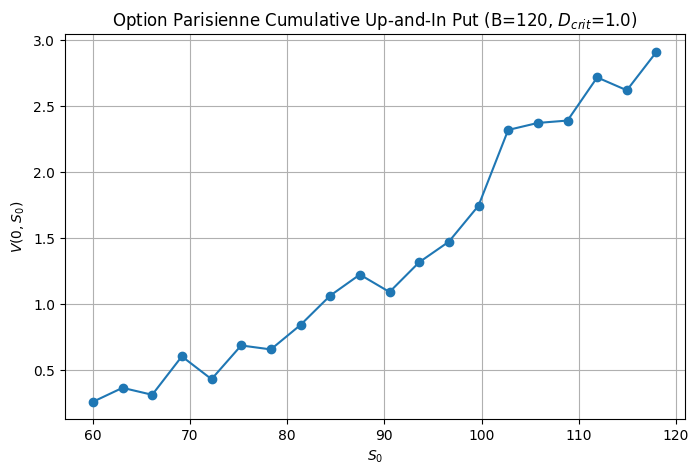

In [18]:
# ─── Up-and-In Put Cumulatif ───
# S'active si le temps total AU-DESSUS de B >= Dcrit
B_up = 120  # Barrière au-dessus du niveau initial
S0_values_up = np.linspace(60, B_up - 2, 20)
Dcrit = 1.0
prix_ui_put = []
for S0 in S0_values_up:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D = temps_au_dessus_barriere(trajectoire, B_up)
        if D >= Dcrit:
            payoff.append(max(K - trajectoire[-1], 0))
        else:
            payoff.append(0)
    prix_ui_put.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values_up, prix_ui_put, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title(f'Option Parisienne Cumulative Up-and-In Put (B={B_up}, $D_{{crit}}$={Dcrit})')
plt.grid(); plt.show()

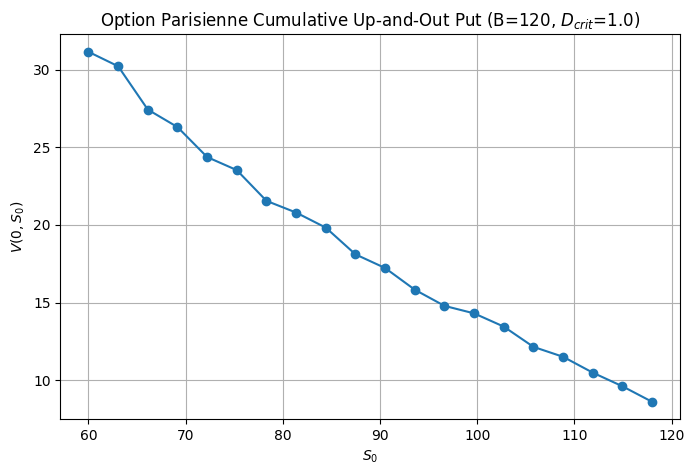

In [19]:
# ─── Up-and-Out Put Cumulatif ───
# CESSE d'exister si le temps total au-dessus de B >= Dcrit
Dcrit = 1.0
prix_uo_put = []
for S0 in S0_values_up:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D = temps_au_dessus_barriere(trajectoire, B_up)
        if D >= Dcrit:
            payoff.append(0)
        else:
            payoff.append(max(K - trajectoire[-1], 0))
    prix_uo_put.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values_up, prix_uo_put, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title(f'Option Parisienne Cumulative Up-and-Out Put (B={B_up}, $D_{{crit}}$={Dcrit})')
plt.grid(); plt.show()

### 3.4 Sensibilités — Grecques de l'option Parisienne Cumulative (Down-and-In Put)

On calcule les trois grecques principales :
- $\Delta_S = \partial V/\partial S_0$ (sensibilité au sous-jacent)
- $\Delta_D = \partial V/\partial D_{crit}$ (sensibilité à l'excursion critique)
- $\Delta_B = \partial V/\partial B$ (sensibilité à la barrière)

Toutes sont estimées par **différences finies centrées** Monte-Carlo.

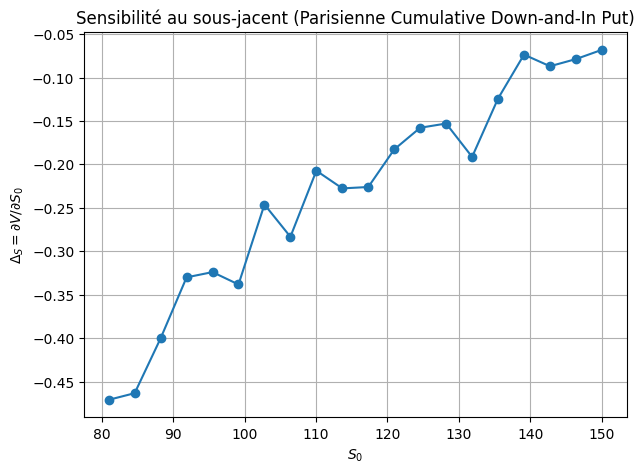

In [20]:
# ─── Delta_S : sensibilité à S0 (Cumulatif Down-and-In Put) ───
h = 1.0
Dcrit = 2.0
B = 80
S0_values = np.linspace(B + 1, 150, 20)
delta_S = np.zeros(len(S0_values))

for i, S0 in enumerate(S0_values):
    somme = []
    for k in range(Nmc):
        Zs = np.random.randn(N)
        # Trajectoire S0 + h
        S_plus = S0 + h
        traj_plus = [S_plus]
        for n in range(N):
            S_plus *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Zs[n])
            traj_plus.append(S_plus)
        # Trajectoire S0 - h (mêmes gaussiennes)
        S_minus = S0 - h
        traj_minus = [S_minus]
        for n in range(N):
            S_minus *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Zs[n])
            traj_minus.append(S_minus)
        D_plus  = temps_sous_barriere(traj_plus,  B)
        D_minus = temps_sous_barriere(traj_minus, B)
        payoff_plus  = max(K - traj_plus[-1],  0) if D_plus  >= Dcrit else 0
        payoff_minus = max(K - traj_minus[-1], 0) if D_minus >= Dcrit else 0
        somme.append((payoff_plus - payoff_minus) / (2 * h))
    delta_S[i] = np.exp(-r*T) * np.mean(somme)

plt.figure(figsize=(7, 5))
plt.plot(S0_values, delta_S, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_S = \partial V/\partial S_0$')
plt.title('Sensibilité au sous-jacent (Parisienne Cumulative Down-and-In Put)')
plt.grid(); plt.show()

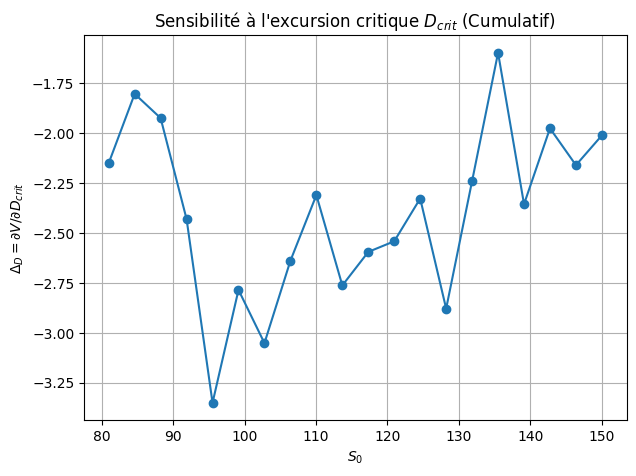

In [21]:
# ─── Delta_D : sensibilité à Dcrit ───
hD = 0.2
Dcrit0 = 2.0
delta_D = []

for S0 in S0_values:
    delta_mc = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for j in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D = temps_sous_barriere(trajectoire, B)
        payoff_plus  = max(K - trajectoire[-1], 0) if D >= Dcrit0 + hD else 0
        payoff_minus = max(K - trajectoire[-1], 0) if D >= Dcrit0 - hD else 0
        delta_mc.append((payoff_plus - payoff_minus) / (2 * hD))
    delta_D.append(np.exp(-r*T) * np.mean(delta_mc))

plt.figure(figsize=(7, 5))
plt.plot(S0_values, delta_D, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_D = \partial V/\partial D_{crit}$')
plt.title("Sensibilité à l'excursion critique $D_{crit}$ (Cumulatif)")
plt.grid(); plt.show()

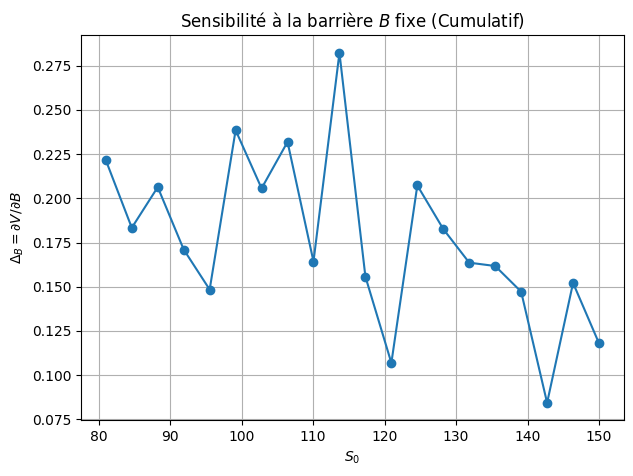

In [22]:
# ─── Delta_B : sensibilité à la barrière B (fixe) ───
hB = 0.5
Dcrit = 2.0
delta_B = []

for S0 in S0_values:
    delta_mc = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_plus  = temps_sous_barriere(trajectoire, B + hB)
        D_minus = temps_sous_barriere(trajectoire, B - hB)
        payoff_plus  = max(K - trajectoire[-1], 0) if D_plus  >= Dcrit else 0
        payoff_minus = max(K - trajectoire[-1], 0) if D_minus >= Dcrit else 0
        delta_mc.append((payoff_plus - payoff_minus) / (2 * hB))
    delta_B.append(np.exp(-r*T) * np.mean(delta_mc))

plt.figure(figsize=(7, 5))
plt.plot(S0_values, delta_B, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_B = \partial V/\partial B$')
plt.title('Sensibilité à la barrière $B$ fixe (Cumulatif)')
plt.grid(); plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
C:\Users\cleme\AppData\Local\Temp\ipykernel_2552\2029297778.py:29: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Sensibilité à la barrière liée $B = 1.5 \cdot S_0$ (Up-and-Out Cumulatif)')


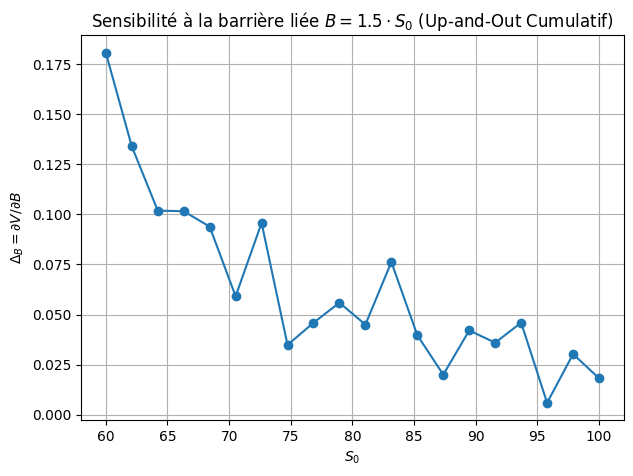

In [23]:
# ─── Delta_B : barrière liée à S0 — B = 1.5 * S0 (Option Up-and-Out) ───
# La barrière évolue proportionnellement au niveau initial du sous-jacent
hB = 0.5
Dcrit = 1.0
S0_values_linked = np.linspace(60, 100, 20)
delta_B_linked = []

for S0 in S0_values_linked:
    B_S0 = 1.5 * S0  # Barrière liée à S0
    delta_mc = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        # Différences finies sur B autour de B(S0) = 1.5 * S0
        D_plus  = temps_au_dessus_barriere(trajectoire, B_S0 + hB)
        D_minus = temps_au_dessus_barriere(trajectoire, B_S0 - hB)
        # Up-and-Out : désactivée si D >= Dcrit
        payoff_plus  = 0 if D_plus  >= Dcrit else max(K - trajectoire[-1], 0)
        payoff_minus = 0 if D_minus >= Dcrit else max(K - trajectoire[-1], 0)
        delta_mc.append((payoff_plus - payoff_minus) / (2 * hB))
    delta_B_linked.append(np.exp(-r*T) * np.mean(delta_mc))

plt.figure(figsize=(7, 5))
plt.plot(S0_values_linked, delta_B_linked, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_B = \partial V/\partial B$')
plt.title('Sensibilité à la barrière liée $B = 1.5 \cdot S_0$ (Up-and-Out Cumulatif)')
plt.grid(); plt.show()

## Section 4 — Options Parisiennes Continues

**Définition** : La condition porte sur la **plus longue excursion continue** au-delà de $B$. L'option est activée/désactivée si cette excursion $D_{max}$ dépasse $D_{crit}$ :
$$D_{max} = \max_i\, D_i \geq D_{crit}$$
où $D_i$ est la durée de la $i$-ème excursion ininterrompue au-delà de $B$.

Cette condition est **plus stricte** que la condition cumulative : l'option continue est plus difficile à activer/désactiver que son équivalent cumulatif.

In [24]:
# ─── Fonction : excursion CONTINUE maximale sous la barrière ───
def excursion_continue(trajectoire, B, dt):
    """Calcule la durée de la plus longue excursion continue SOUS la barrière B."""
    D_max = 0.0
    D_courant = 0.0
    for i in range(len(trajectoire) - 1):
        S1 = trajectoire[i]
        S2 = trajectoire[i + 1]
        if S1 < B and S2 < B:
            D_courant += dt
        elif S1 >= B and S2 < B:   # Entrée
            frac = (B - S2) / (S1 - S2)
            D_courant += frac * dt
        elif S1 < B and S2 >= B:   # Sortie -> fin d'excursion
            frac = (B - S1) / (S2 - S1)
            D_courant += frac * dt
            D_max = max(D_max, D_courant)
            D_courant = 0.0
        else:
            D_max = max(D_max, D_courant)
            D_courant = 0.0
        D_max = max(D_max, D_courant)
    return D_max

# ─── Fonction : excursion CONTINUE maximale AU-DESSUS de la barrière ───
def excursion_continue_up(trajectoire, B, dt):
    """Calcule la durée de la plus longue excursion continue AU-DESSUS de la barrière B."""
    D_max = 0.0
    D_courant = 0.0
    for i in range(len(trajectoire) - 1):
        S1 = trajectoire[i]
        S2 = trajectoire[i + 1]
        if S1 > B and S2 > B:
            D_courant += dt
        elif S1 <= B and S2 > B:   # Entrée au-dessus
            frac = (S2 - B) / (S2 - S1)
            D_courant += frac * dt
        elif S1 > B and S2 <= B:   # Sortie -> fin d'excursion
            frac = (S1 - B) / (S1 - S2)
            D_courant += frac * dt
            D_max = max(D_max, D_courant)
            D_courant = 0.0
        else:
            D_max = max(D_max, D_courant)
            D_courant = 0.0
        D_max = max(D_max, D_courant)
    return D_max

print('Fonctions helper continues définies.')

Fonctions helper continues définies.


### 4.1 Prix des options Parisiennes Continues — Down variants

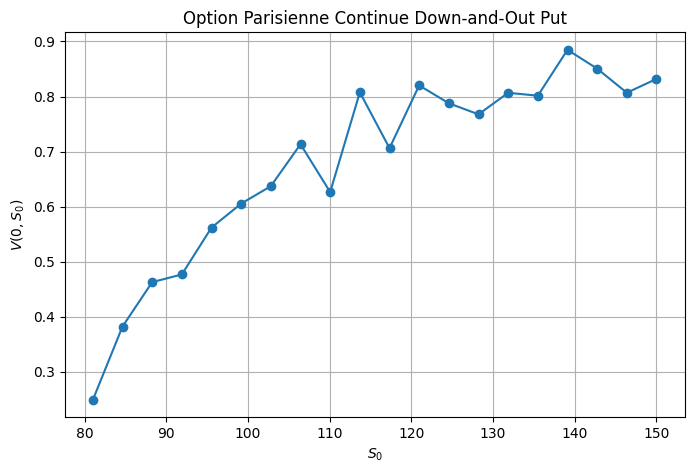

In [25]:
# ─── Down-and-Out Put Continu ───
# L'option cesse d'exister si la plus longue excursion sous B >= Dcrit
B = 80; K = 100; r = 0.04; sigma = 0.3; T = 5
N = 500; dt = T / N; Nmc = 5000
Dcrit = 0.2
S0_values = np.linspace(B + 1, 150, 20)

prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_max = excursion_continue(trajectoire, B, dt)
        if D_max >= Dcrit:
            payoff.append(0)
        else:
            payoff.append(max(K - trajectoire[-1], 0))
    prix_option.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title('Option Parisienne Continue Down-and-Out Put')
plt.grid(); plt.show()

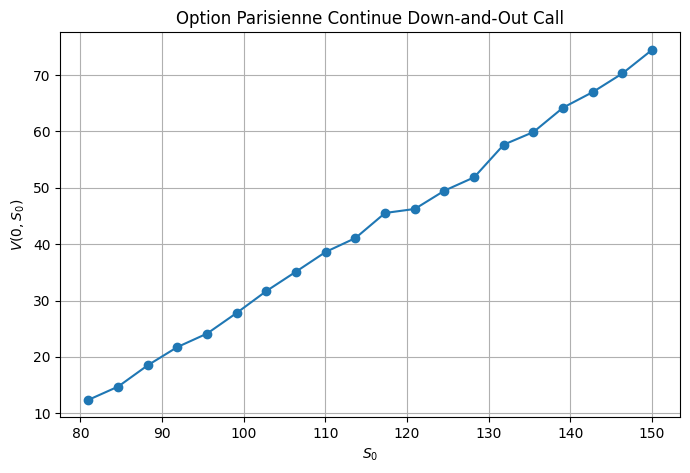

In [26]:
# ─── Down-and-Out Call Continu ───
prix_option = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_max = excursion_continue(trajectoire, B, dt)
        if D_max >= Dcrit:
            payoff.append(0)
        else:
            payoff.append(max(trajectoire[-1] - K, 0))
    prix_option.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values, prix_option, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title('Option Parisienne Continue Down-and-Out Call')
plt.grid(); plt.show()

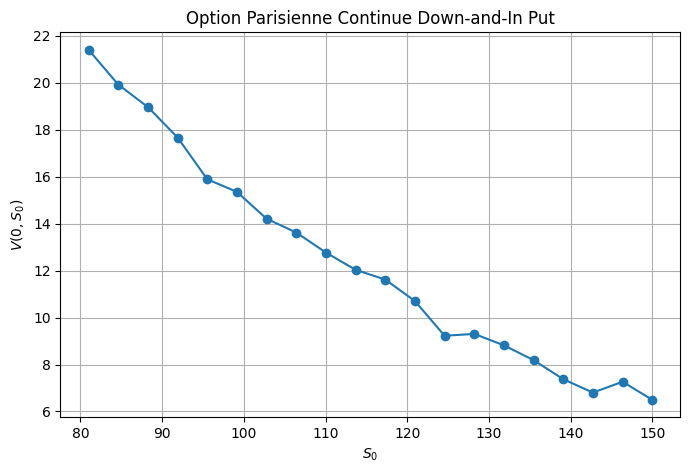

In [27]:
# ─── Down-and-In Put Continu ───
# S'active si la plus longue excursion sous B >= Dcrit
prix_di_cont = []
for S0 in S0_values:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_max = excursion_continue(trajectoire, B, dt)
        if D_max >= Dcrit:
            payoff.append(max(K - trajectoire[-1], 0))
        else:
            payoff.append(0)
    prix_di_cont.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values, prix_di_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title('Option Parisienne Continue Down-and-In Put')
plt.grid(); plt.show()

### 4.2 Prix des options Parisiennes Continues — Up variants

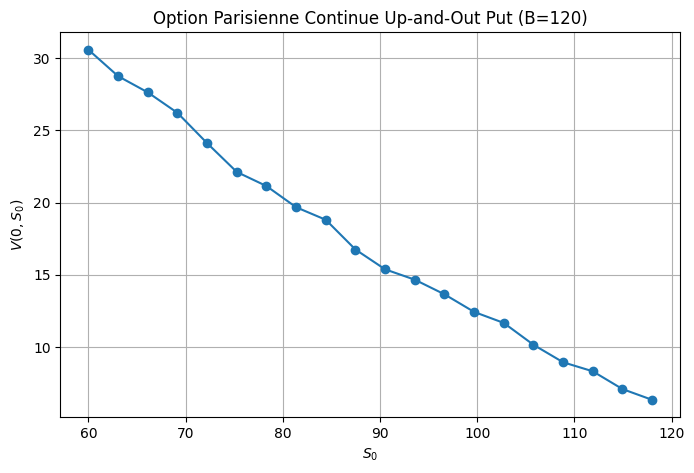

In [28]:
# ─── Up-and-Out Put Continu ───
# Désactivée si la plus longue excursion AU-DESSUS de B_up >= Dcrit
B_up = 120; Dcrit = 0.2
S0_values_up = np.linspace(60, B_up - 2, 20)

prix_uo_cont = []
for S0 in S0_values_up:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_max = excursion_continue_up(trajectoire, B_up, dt)
        if D_max >= Dcrit:
            payoff.append(0)
        else:
            payoff.append(max(K - trajectoire[-1], 0))
    prix_uo_cont.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values_up, prix_uo_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title(f'Option Parisienne Continue Up-and-Out Put (B={B_up})')
plt.grid(); plt.show()

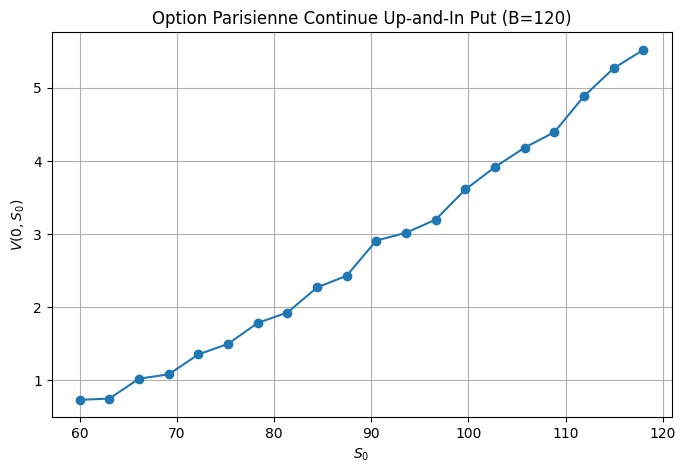

In [29]:
# ─── Up-and-In Put Continu ───
# S'active si la plus longue excursion AU-DESSUS de B_up >= Dcrit
prix_ui_cont = []
for S0 in S0_values_up:
    payoff = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_max = excursion_continue_up(trajectoire, B_up, dt)
        if D_max >= Dcrit:
            payoff.append(max(K - trajectoire[-1], 0))
        else:
            payoff.append(0)
    prix_ui_cont.append(np.exp(-r*T) * np.mean(payoff))

plt.figure(figsize=(8, 5))
plt.plot(S0_values_up, prix_ui_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel('$V(0,S_0)$')
plt.title(f'Option Parisienne Continue Up-and-In Put (B={B_up})')
plt.grid(); plt.show()

### 4.3 Graphe $S_0 \mapsto V(0, S_0, D_{crit})$ pour plusieurs $D_{crit}$ (Continu)

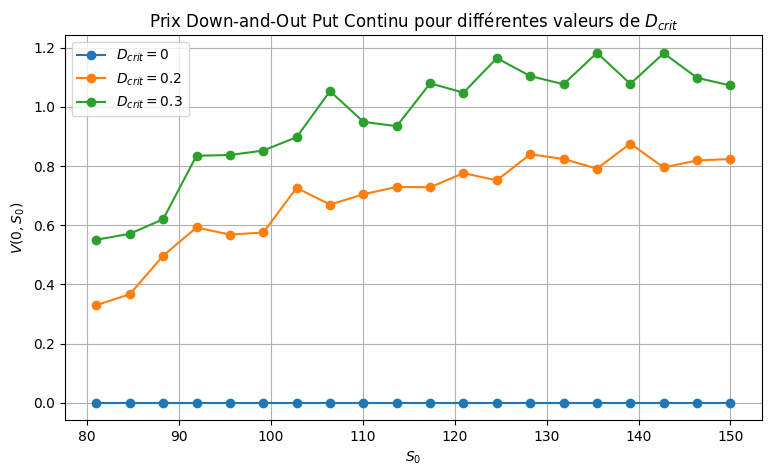

In [30]:
# ─── S0 → V pour Dcrit = 0, 0.2, 0.3 (Down-and-Out Put Continu) ───
B = 80; S0_values = np.linspace(B+1, 150, 20)
Dcrit_list_cont = [0, 0.2, 0.3]

plt.figure(figsize=(9, 5))
for Dcrit_val in Dcrit_list_cont:
    prix_tmp = []
    for S0 in S0_values:
        payoff = []
        for k in range(Nmc):
            S = S0; trajectoire = [S]
            for _ in range(N):
                Z = np.random.randn()
                S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
                trajectoire.append(S)
            D_max = excursion_continue(trajectoire, B, dt)
            if D_max >= Dcrit_val:
                payoff.append(0)
            else:
                payoff.append(max(K - trajectoire[-1], 0))
        prix_tmp.append(np.exp(-r*T) * np.mean(payoff))
    plt.plot(S0_values, prix_tmp, marker='o', label=f'$D_{{crit}}={Dcrit_val}$')

plt.xlabel('$S_0$'); plt.ylabel('$V(0, S_0)$')
plt.title('Prix Down-and-Out Put Continu pour différentes valeurs de $D_{crit}$')
plt.legend(); plt.grid(); plt.show()

### 4.4 Surface de prix et Grecques (Continu — Down-and-Out Put)

On calcule la surface $V(S_0, D_{crit})$ pour le type continu, avec sa propre grille de simulation.

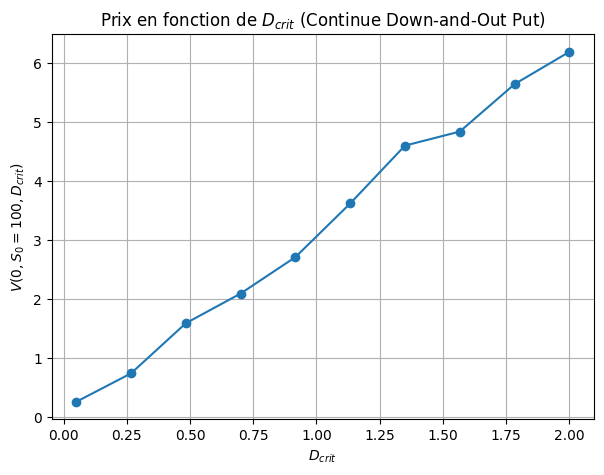

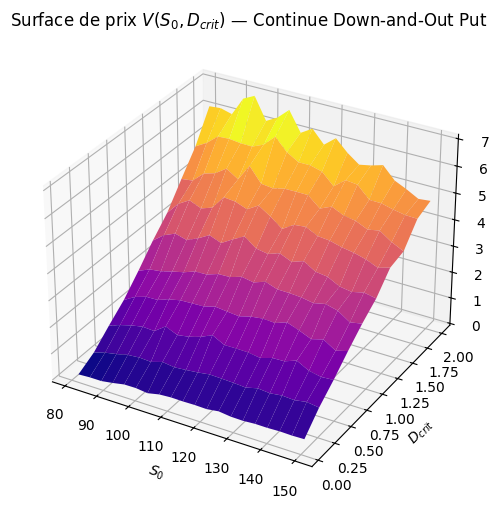

In [31]:
# ─── Surface V(S0, Dcrit) — Down-and-Out Put Continu ───
B = 80
S0_values   = np.linspace(B + 1, 150, 20)
Dcrit_values = np.linspace(0.05, 2, 10)
prix_surface_cont = np.zeros((len(S0_values), len(Dcrit_values)))

for i, S0 in enumerate(S0_values):
    for j, Dcrit in enumerate(Dcrit_values):
        payoff = []
        for k in range(Nmc):
            S = S0; trajectoire = [S]
            for _ in range(N):
                Z = np.random.randn()
                S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
                trajectoire.append(S)
            D_max = excursion_continue(trajectoire, B, dt)
            if D_max >= Dcrit:
                payoff.append(0)
            else:
                payoff.append(max(K - trajectoire[-1], 0))
        prix_surface_cont[i, j] = np.exp(-r*T) * np.mean(payoff)

# Tracé Dcrit → V pour S0 fixé
S0_fixed = 100
idx = np.argmin(np.abs(S0_values - S0_fixed))
plt.figure(figsize=(7, 5))
plt.plot(Dcrit_values, prix_surface_cont[idx, :], marker='o')
plt.xlabel('$D_{crit}$'); plt.ylabel(f'$V(0, S_0={S0_fixed}, D_{{crit}})$')
plt.title('Prix en fonction de $D_{crit}$ (Continue Down-and-Out Put)')
plt.grid(); plt.show()

# Surface 3D
S0_grid, Dcrit_grid = np.meshgrid(S0_values, Dcrit_values, indexing='ij')
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S0_grid, Dcrit_grid, prix_surface_cont, cmap='plasma')
ax.set_xlabel('$S_0$'); ax.set_ylabel('$D_{crit}$'); ax.set_zlabel('$V$')
ax.set_title('Surface de prix $V(S_0, D_{crit})$ — Continue Down-and-Out Put')
plt.show()

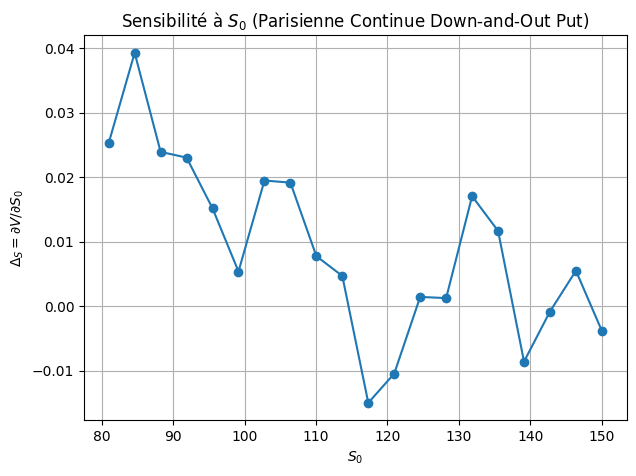

In [32]:
# ─── Delta_S continu (Down-and-Out Put) ───
h = 1.0; Dcrit = 0.2; B = 80
S0_values = np.linspace(B + 1, 150, 20)
delta_cont = np.zeros(len(S0_values))

for i, S0 in enumerate(S0_values):
    somme = []
    for k in range(Nmc):
        Zs = np.random.randn(N)
        S_plus = S0 + h
        traj_plus = [S_plus]
        for n in range(N):
            S_plus *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Zs[n])
            traj_plus.append(S_plus)
        S_minus = S0 - h
        traj_minus = [S_minus]
        for n in range(N):
            S_minus *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Zs[n])
            traj_minus.append(S_minus)
        D_plus  = excursion_continue(traj_plus,  B, dt)
        D_minus = excursion_continue(traj_minus, B, dt)
        payoff_plus  = max(K - traj_plus[-1],  0) if D_plus  <= Dcrit else 0
        payoff_minus = max(K - traj_minus[-1], 0) if D_minus <= Dcrit else 0
        somme.append((payoff_plus - payoff_minus) / (2 * h))
    delta_cont[i] = np.exp(-r*T) * np.mean(somme)

plt.figure(figsize=(7, 5))
plt.plot(S0_values, delta_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_S = \partial V/\partial S_0$')
plt.title('Sensibilité à $S_0$ (Parisienne Continue Down-and-Out Put)')
plt.grid(); plt.show()

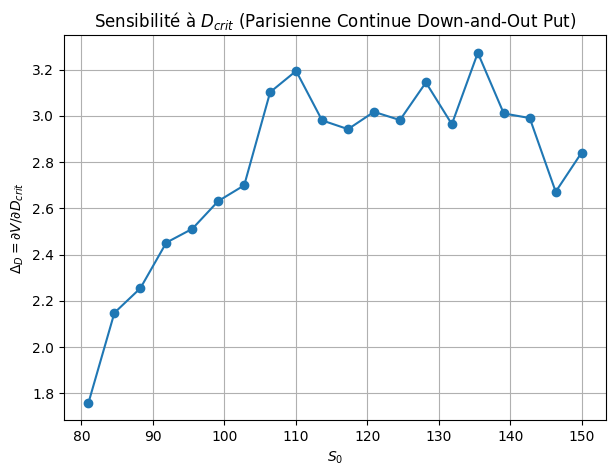

In [33]:
# ─── Delta_D continu ───
hD = 0.2; Dcrit0 = 0.2
delta_D_cont = []

for S0 in S0_values:
    delta_mc = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for j in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D = excursion_continue(trajectoire, B, dt)
        payoff_plus  = max(K - trajectoire[-1], 0) if D <= Dcrit0 + hD else 0
        payoff_minus = max(K - trajectoire[-1], 0) if D <= Dcrit0 - hD else 0
        delta_mc.append((payoff_plus - payoff_minus) / (2 * hD))
    delta_D_cont.append(np.exp(-r*T) * np.mean(delta_mc))

plt.figure(figsize=(7, 5))
plt.plot(S0_values, delta_D_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_D = \partial V/\partial D_{crit}$')
plt.title("Sensibilité à $D_{crit}$ (Parisienne Continue Down-and-Out Put)")
plt.grid(); plt.show()

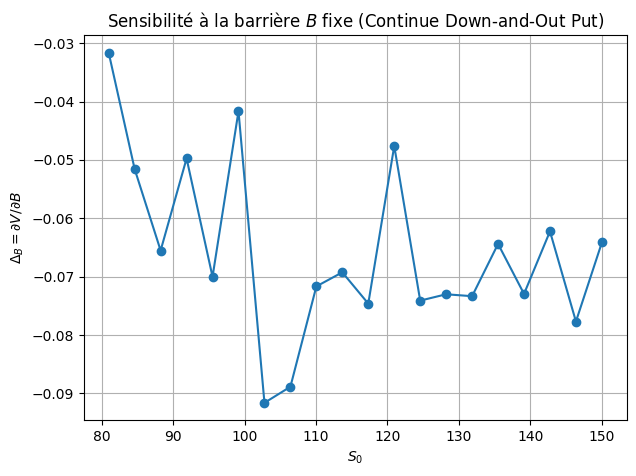

In [34]:
# ─── Delta_B continu fixe ───
hB = 0.5; Dcrit = 0.2
delta_B_cont = []

for S0 in S0_values:
    delta_mc = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_plus  = excursion_continue(trajectoire, B + hB, dt)
        D_minus = excursion_continue(trajectoire, B - hB, dt)
        payoff_plus  = 0 if D_plus  >= Dcrit else max(K - trajectoire[-1], 0)
        payoff_minus = 0 if D_minus >= Dcrit else max(K - trajectoire[-1], 0)
        delta_mc.append((payoff_plus - payoff_minus) / (2 * hB))
    delta_B_cont.append(np.exp(-r*T) * np.mean(delta_mc))

plt.figure(figsize=(7, 5))
plt.plot(S0_values, delta_B_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_B = \partial V/\partial B$')
plt.title('Sensibilité à la barrière $B$ fixe (Continue Down-and-Out Put)')
plt.grid(); plt.show()

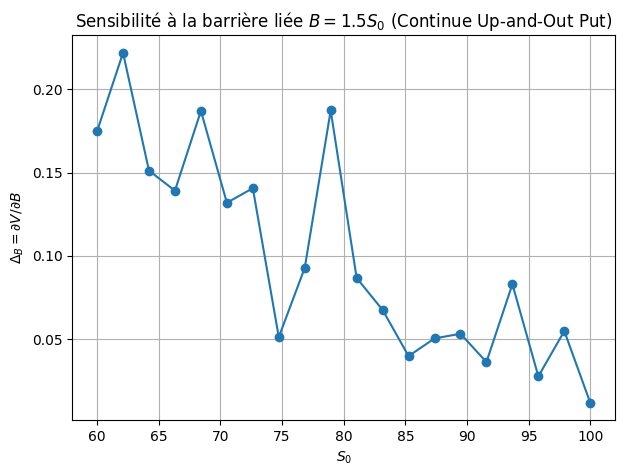

In [35]:
# ─── Delta_B continu : barrière liée à S0 — B = 1.5 * S0 (Up-and-Out) ───
hB = 0.5; Dcrit = 0.2
S0_values_linked = np.linspace(60, 100, 20)
delta_B_linked_cont = []

for S0 in S0_values_linked:
    B_S0 = 1.5 * S0
    delta_mc = []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for i in range(N):
            Z = np.random.randn()
            S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_plus  = excursion_continue_up(trajectoire, B_S0 + hB, dt)
        D_minus = excursion_continue_up(trajectoire, B_S0 - hB, dt)
        payoff_plus  = 0 if D_plus  >= Dcrit else max(K - trajectoire[-1], 0)
        payoff_minus = 0 if D_minus >= Dcrit else max(K - trajectoire[-1], 0)
        delta_mc.append((payoff_plus - payoff_minus) / (2 * hB))
    delta_B_linked_cont.append(np.exp(-r*T) * np.mean(delta_mc))

plt.figure(figsize=(7, 5))
plt.plot(S0_values_linked, delta_B_linked_cont, marker='o')
plt.xlabel('$S_0$'); plt.ylabel(r'$\Delta_B = \partial V/\partial B$')
plt.title('Sensibilité à la barrière liée $B=1.5 S_0$ (Continue Up-and-Out Put)')
plt.grid(); plt.show()

---
## Section 4b — Comparaison Cumulative vs Continue

On compare les prix de la **Down-and-In Put** Cumulative et Continue sur la même grille de $S_0$, pour le même $D_{crit}$.

**Intuition** : à $D_{crit}$ égal, l'option cumulative est *plus facile* à activer (elle somme tous les passages sous $B$), donc son prix est en général **plus élevé** que l'option continue (qui exige une seule excursion ininterrompue de même durée).

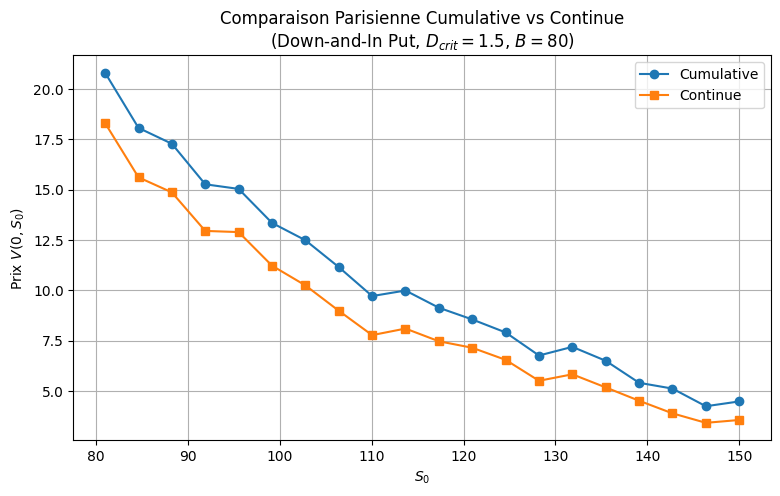

Différence moyenne de prix (Cumul - Continu) : 1.7222


In [36]:
# ─── Comparaison Cumulative vs Continue — Down-and-In Put ───
B = 80; K = 100; r = 0.04; sigma = 0.3; T = 5; N = 500; dt = T/N; Nmc = 2000
Dcrit_comp = 1.5
S0_values = np.linspace(B + 1, 150, 20)

prix_cumul_comp = []
prix_cont_comp  = []

for S0 in S0_values:
    pc_c, pc_k = [], []
    for k in range(Nmc):
        S = S0; trajectoire = [S]
        for _ in range(N):
            Z = np.random.randn()
            S *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            trajectoire.append(S)
        D_cum  = temps_sous_barriere(trajectoire, B)
        D_cont = excursion_continue(trajectoire, B, dt)
        # Down-and-In : payoff si D >= Dcrit
        pc_c.append(max(K - trajectoire[-1], 0) if D_cum  >= Dcrit_comp else 0)
        pc_k.append(max(K - trajectoire[-1], 0) if D_cont >= Dcrit_comp else 0)
    prix_cumul_comp.append(np.exp(-r*T) * np.mean(pc_c))
    prix_cont_comp.append(np.exp(-r*T)  * np.mean(pc_k))

plt.figure(figsize=(9, 5))
plt.plot(S0_values, prix_cumul_comp, marker='o', label='Cumulative')
plt.plot(S0_values, prix_cont_comp,  marker='s', label='Continue')
plt.xlabel('$S_0$'); plt.ylabel('Prix $V(0, S_0)$')
plt.title(f'Comparaison Parisienne Cumulative vs Continue\n'
          f'(Down-and-In Put, $D_{{crit}}={Dcrit_comp}$, $B={B}$)')
plt.legend(); plt.grid(); plt.show()

print('Différence moyenne de prix (Cumul - Continu) :', 
      f'{np.mean(np.array(prix_cumul_comp) - np.array(prix_cont_comp)):.4f}')

---
## Section 5 — Value at Risk (VaR)

La **VaR** répond à l'affirmation : *"Nous sommes certains à la probabilité $1-\alpha$ que nous n'allons pas perdre plus de VaR euros sur $T$ prochains jours."*

$$P\left[V_T - V_0 e^{rT} \leq \text{VaR}\right] = \alpha$$

où $V_T$ est le pay-off (non actualisé) de l'option, et $V_0$ est son prix à $t=0$.

**Algorithme :**
1. Simuler $N_{MC}$ pay-offs $V_T^{(k)}$ sans actualisation
2. Calculer la variable de perte : $L^{(k)} = V_T^{(k)} - V_0 e^{rT}$
3. Trier l'échantillon, puis $\text{VaR}_\alpha = L_{(k)}$ avec $k = \lfloor N_{MC} \cdot \alpha \rfloor$

Prix V0 (Cumulative Down-and-In Put, Dcrit=2.0) = 12.1867
VaR (alpha=10%) = -14.8849
VaR (alpha=1%) = -14.8849


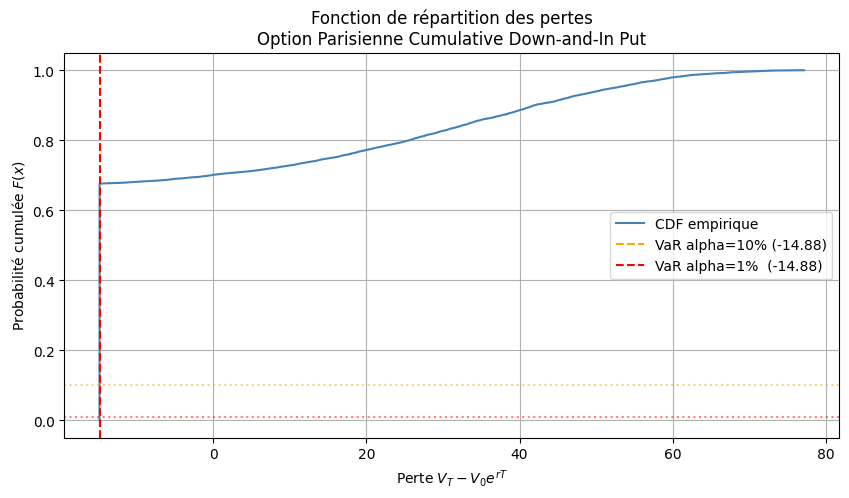

In [37]:
# ─── VaR — Option Parisienne Cumulative (Down-and-In Put) ───
B = 80; K = 100; r = 0.04; sigma = 0.3; T = 5
N = 500; dt = T / N; Nmc_var = 10000
Dcrit = 2.0; S0 = 100

# Étape 1 : simuler les pay-offs bruts (sans actualisation)
payoffs_VT_cumul = []
for k in range(Nmc_var):
    S = S0; trajectoire = [S]
    for i in range(N):
        Z = np.random.randn()
        S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
        trajectoire.append(S)
    D = temps_sous_barriere(trajectoire, B)
    if D >= Dcrit:
        payoffs_VT_cumul.append(max(K - trajectoire[-1], 0))
    else:
        payoffs_VT_cumul.append(0)

payoffs_VT_cumul = np.array(payoffs_VT_cumul)
V0_cumul = np.exp(-r * T) * np.mean(payoffs_VT_cumul)
print(f'Prix V0 (Cumulative Down-and-In Put, Dcrit={Dcrit}) = {V0_cumul:.4f}')

# Étape 2 : variable de perte L = V_T - V0 * e^{rT}
pertes_cumul = payoffs_VT_cumul - V0_cumul * np.exp(r * T)

# Étape 3 : VaR par algorithme d'ordonnement
pertes_triees_cumul = np.sort(pertes_cumul)

for alpha in [0.10, 0.01]:
    k_idx = int(Nmc_var * alpha)
    VaR = pertes_triees_cumul[k_idx]
    print(f'VaR (alpha={alpha:.0%}) = {VaR:.4f}')

# Tracé de la fonction de répartition empirique
x_vals = pertes_triees_cumul
cdf_vals = np.arange(1, Nmc_var + 1) / Nmc_var

k10 = int(Nmc_var * 0.10)
k01 = int(Nmc_var * 0.01)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, cdf_vals, label='CDF empirique', color='steelblue')
plt.axvline(pertes_triees_cumul[k10], color='orange', linestyle='--',
            label=f'VaR alpha=10% ({pertes_triees_cumul[k10]:.2f})')
plt.axvline(pertes_triees_cumul[k01], color='red', linestyle='--',
            label=f'VaR alpha=1%  ({pertes_triees_cumul[k01]:.2f})')
plt.axhline(0.10, color='orange', linestyle=':', alpha=0.5)
plt.axhline(0.01, color='red',    linestyle=':', alpha=0.5)
plt.xlabel('Perte $V_T - V_0 e^{rT}$')
plt.ylabel('Probabilité cumulée $F(x)$')
plt.title('Fonction de répartition des pertes\nOption Parisienne Cumulative Down-and-In Put')
plt.legend(); plt.grid(); plt.show()

Prix V0 (Continue Down-and-Out Put, Dcrit=0.2) = 0.6718
VaR (alpha=10%) = -0.8206
VaR (alpha=1%) = -0.8206


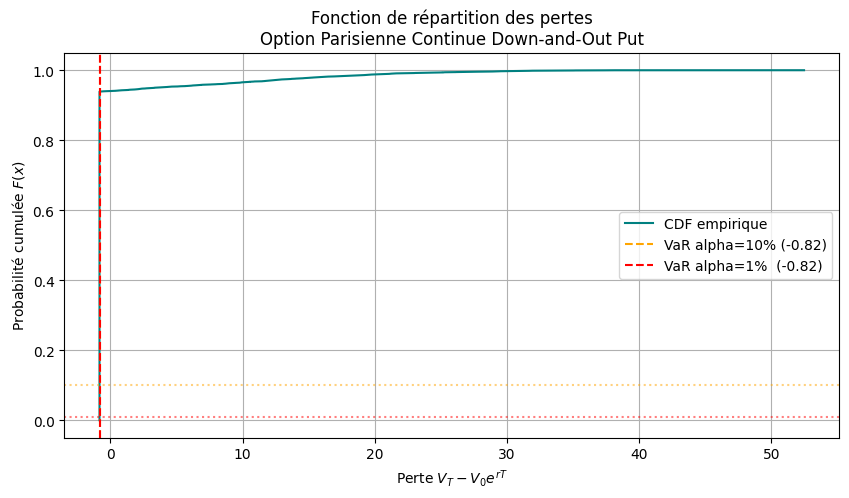

In [38]:
# ─── VaR — Option Parisienne Continue (Down-and-Out Put) ───
Dcrit = 0.2; S0 = 100

# Étape 1 : pay-offs bruts
payoffs_VT_cont = []
for k in range(Nmc_var):
    S = S0; trajectoire = [S]
    for i in range(N):
        Z = np.random.randn()
        S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
        trajectoire.append(S)
    D_max = excursion_continue(trajectoire, B, dt)
    if D_max >= Dcrit:
        payoffs_VT_cont.append(0)
    else:
        payoffs_VT_cont.append(max(K - trajectoire[-1], 0))

payoffs_VT_cont = np.array(payoffs_VT_cont)
V0_cont = np.exp(-r * T) * np.mean(payoffs_VT_cont)
print(f'Prix V0 (Continue Down-and-Out Put, Dcrit={Dcrit}) = {V0_cont:.4f}')

# Étape 2 : perte
pertes_cont = payoffs_VT_cont - V0_cont * np.exp(r * T)

# Étape 3 : VaR
pertes_triees_cont = np.sort(pertes_cont)

for alpha in [0.10, 0.01]:
    k_idx = int(Nmc_var * alpha)
    VaR = pertes_triees_cont[k_idx]
    print(f'VaR (alpha={alpha:.0%}) = {VaR:.4f}')

# Tracé
x_vals_cont = pertes_triees_cont
cdf_vals_cont = np.arange(1, Nmc_var + 1) / Nmc_var

k10c = int(Nmc_var * 0.10)
k01c = int(Nmc_var * 0.01)

plt.figure(figsize=(10, 5))
plt.plot(x_vals_cont, cdf_vals_cont, label='CDF empirique', color='teal')
plt.axvline(pertes_triees_cont[k10c], color='orange', linestyle='--',
            label=f'VaR alpha=10% ({pertes_triees_cont[k10c]:.2f})')
plt.axvline(pertes_triees_cont[k01c], color='red', linestyle='--',
            label=f'VaR alpha=1%  ({pertes_triees_cont[k01c]:.2f})')
plt.axhline(0.10, color='orange', linestyle=':', alpha=0.5)
plt.axhline(0.01, color='red',    linestyle=':', alpha=0.5)
plt.xlabel('Perte $V_T - V_0 e^{rT}$')
plt.ylabel('Probabilité cumulée $F(x)$')
plt.title('Fonction de répartition des pertes\nOption Parisienne Continue Down-and-Out Put')
plt.legend(); plt.grid(); plt.show()

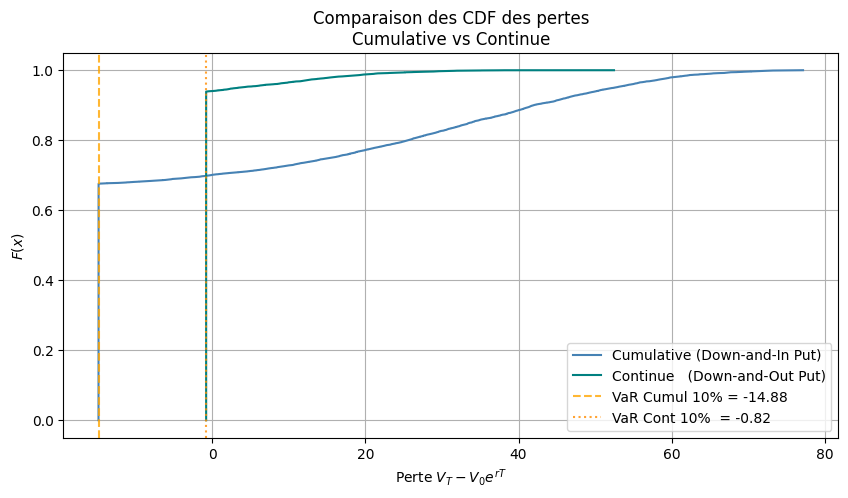

In [39]:
# ─── Comparaison des deux CDF sur le même graphe ───
plt.figure(figsize=(10, 5))
plt.plot(x_vals,      cdf_vals,      label='Cumulative (Down-and-In Put)', color='steelblue')
plt.plot(x_vals_cont, cdf_vals_cont, label='Continue   (Down-and-Out Put)', color='teal')

# Marquage des VaR alpha=10%
plt.axvline(pertes_triees_cumul[k10],  color='orange', linestyle='--', alpha=0.8,
            label=f'VaR Cumul 10% = {pertes_triees_cumul[k10]:.2f}')
plt.axvline(pertes_triees_cont[k10c],  color='darkorange', linestyle=':',  alpha=0.8,
            label=f'VaR Cont 10%  = {pertes_triees_cont[k10c]:.2f}')

plt.xlabel('Perte $V_T - V_0 e^{rT}$')
plt.ylabel('$F(x)$')
plt.title('Comparaison des CDF des pertes\nCumulative vs Continue')
plt.legend(); plt.grid(); plt.show()

---
# Section 6 — Ouverture : Extensions et Perspectives

## Les Options Parisiennes dans la littérature et la pratique

### Contexte historique
Les options Parisiennes ont été introduites par **Chesney, Jeanblanc-Picqué et Yor (1997)** dans l'article fondateur *"Brownian Excursions and Parisian Barrier Options"*. Leur nom vient du fait qu'elles imposent une condition temporelle sur l'excursion du sous-jacent, en référence à la règle de durée d'absence appliquée lors du Tour de France (on est éliminé si l'on reste trop longtemps en dehors du peloton).

### Avantages par rapport aux options à barrière classiques
Les options Parisiennes présentent plusieurs avantages :
- **Robustesse à la manipulation de marché** : contrairement aux barrières classiques, il est très difficile pour un acteur de marché de provoquer artificiellement l'activation en "touchant" brièvement la barrière. Le sous-jacent doit rester suffisamment longtemps au-delà de $B$ pour déclencher la condition.
- **Primes réduites** : les options Parisiennes Down-and-Out sont moins chères que leurs équivalents classiques car elles sont plus difficiles à désactiver.
- **Gestion du risque affinée** : elles permettent de modéliser des situations réelles où une condition de défaut ou d'activation ne s'applique qu'après une période prolongée de stress (par exemple, clauses de défaut dans les contrats obligataires).

### Méthodes de pricing analytique
Chesney et al. ont dérivé des **formules semi-analytiques** basées sur les excursions du mouvement brownien. Ces formules font intervenir des fonctions spéciales liées à la distribution de la longueur des excursions du mouvement brownien standard. En pratique, pour le type continu, le prix peut s'écrire :
$$V_0 = e^{-rT} \mathbb{E}^Q\left[\Phi(S_T) \cdot \mathbf{1}_{D_{max} \geq D_{crit}}\right]$$
où $\mathbb{E}^Q$ est l'espérance sous la mesure risque-neutre $Q$.

### Pistes d'extension pour ce projet
Plusieurs directions d'approfondissement sont possibles :

1. **Méthode PDE** : résoudre numériquement l'EDP associée à l'option Parisienne en ajoutant une dimension d'état représentant le temps passé au-delà de $B$. Cette approche offre une convergence plus rapide que Monte-Carlo pour les options de type Down-and-Out.

2. **Formules analytiques (Laplace)** : l'article de Chesney et al. exploite la transformée de Laplace par rapport au temps $T$ pour obtenir des expressions fermées. L'inversion numérique de Laplace (méthode de Gaver-Stehfest) permet de retrouver des prix sans simulation.

3. **Options Parisiennes sur taux d'intérêt** : les options Parisiennes trouvent des applications naturelles dans la modélisation du défaut des entreprises (modèles de crédit structurés). Si le ratio actif/dette d'une entreprise reste trop longtemps en dessous d'un seuil critique, l'entreprise est déclarée en défaut.

4. **Options Parisiennes asymétriques** : on peut envisager des barrières où la durée critique $D_{crit}$ est différente selon que l'on est au-dessus ou en dessous de $B$, offrant une plus grande flexibilité dans la gestion du risque.

5. **Contrôle de variance Monte-Carlo** : les estimateurs Monte-Carlo présentés dans ce projet peuvent être améliorés par des techniques de réduction de variance : variables antithétiques, variables de contrôle (en utilisant le prix de l'option barrière classique comme variable de contrôle), ou quasi-Monte-Carlo (suites de Sobol).

### Références
- Chesney M., Jeanblanc-Picqué M., Yor M. (1997). *Brownian Excursions and Parisian Barrier Options*. Advances in Applied Probability, 29(1), 165–184.
- Labart C., Lelong J. (2009). *Pricing Parisian Options Using Laplace Transforms*. Bankers, Markets & Investors.
- Glasserman P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer.